# **Customer Churn Prediction & Revenue-at-Risk Analysis**
**Author:** Filip Handjiski

**Data:** IBM Telco Customer Churn dataset (7,043 customers of a U.S. telecom company)
**Source:** [IBM on GitHub](https://github.com/IBM/telco-customer-churn-on-icp4d) / Kaggle

## Business Problem
A telecom company is losing customers. This project answers three questions:
1. Which customers are most likely to leave (churn), and why?
2. How much yearly revenue is at risk?
3. What should the company do to keep them, and how much could it save?

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Load the Data

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv")

print('Rows and columns:', df.shape)
df.head()

Rows and columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## **Data Cleaning**
### Step 1: Check duplicates and missing values

In [4]:
print('Duplicate rows:', df.duplicated().sum())
print('Duplicate customer IDs:', df['customerID'].duplicated().sum())
print('Missing values:', df.isnull().sum().sum())

Duplicate rows: 0
Duplicate customer IDs: 0
Missing values: 0


### Step 2: Fix TotalCharges
TotalCharges is stored as text because some cells contain a blank space instead of a number. We convert it to a number and check which rows were blank.

In [5]:
print('Blank TotalCharges:', (df['TotalCharges'].str.strip() == '').sum())

# Convert to a number; blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print('TotalCharges now missing:', df['TotalCharges'].isnull().sum())

# Look at the blank rows
df[df['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

Blank TotalCharges: 11
TotalCharges now missing: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


In [6]:
# New customers haven't been billed yet, so their total is 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print('Missing values left:', df['TotalCharges'].isnull().sum()) #Check for missing values after modification

Missing values left: 0


### Step 3: Turn Churn into a number
The model needs numbers, so we create Churn_Flag: 1 = left, 0 = stayed.

In [7]:
df['Churn_Flag'] = (df['Churn'] == 'Yes').astype(int)
df[['Churn', 'Churn_Flag']].head()

,Churn,Churn_Flag
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


> **So what:** The data was clean except for [X] blank TotalCharges values, all belonging to brand-new customers (tenure = 0). We set them to 0, since those customers hadn't been billed yet. No duplicates were found.

## **Exploratory Analysis**
### Q1: How many customers churn in total?

In [8]:
churn_rate = df['Churn_Flag'].mean() * 100
print('Overall churn rate:', round(churn_rate, 1), '%')
print(df['Churn'].value_counts())

Overall churn rate: 26.5 %
Churn
No     5174
Yes    1869
Name: count, dtype: int64


### Q2: Does contract type affect churn?

Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: Churn_Flag, dtype: float64


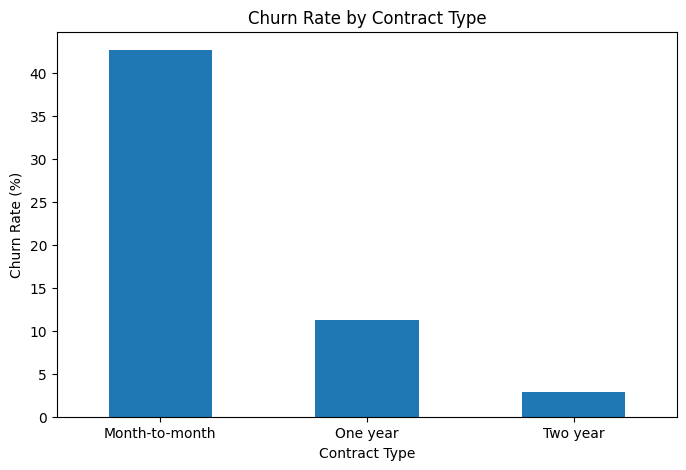

In [9]:
churn_by_contract = df.groupby('Contract')['Churn_Flag'].mean() * 100
print(churn_by_contract.round(1))

churn_by_contract.plot(kind='bar', figsize=(8, 5), title='Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

>**Key finding:** Month-to-month (new) customers are substantially more likely to churn

### Q3: Do newer customers churn more?

Tenure Group
0-12 months     47.4
13-24 months    28.7
25-48 months    20.4
49-72 months     9.5
Name: Churn_Flag, dtype: float64


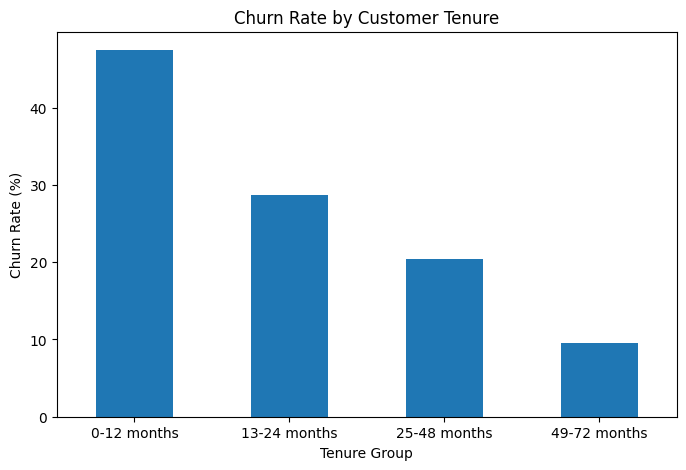

In [10]:
# Group customers by how long they've stayed
df['Tenure Group'] = pd.cut(df['tenure'], bins=[-1, 12, 24, 48, 72],
                            labels=['0-12 months', '13-24 months', '25-48 months', '49-72 months'])

churn_by_tenure = df.groupby('Tenure Group', observed=True)['Churn_Flag'].mean() * 100
print(churn_by_tenure.round(1))

churn_by_tenure.plot(kind='bar', figsize=(8, 5), title='Churn Rate by Customer Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.show()

### Q4: Do customers who leave pay more?

        count  mean   std   min   25%   50%   75%    max
Churn                                                   
No     5174.0  61.3  31.1  18.2  25.1  64.4  88.4  118.8
Yes    1869.0  74.4  24.7  18.8  56.2  79.6  94.2  118.4


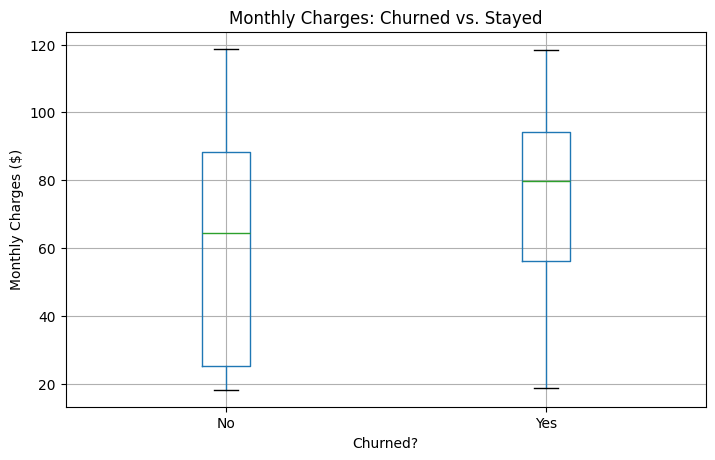

In [11]:
print(df.groupby('Churn')['MonthlyCharges'].describe().round(1))

df.boxplot(column='MonthlyCharges', by='Churn', figsize=(8, 5))
plt.title('Monthly Charges: Churned vs. Stayed')
plt.suptitle('')
plt.xlabel('Churned?')
plt.ylabel('Monthly Charges ($)')
plt.show()

### Q5: Which services and payment methods have the highest churn?

In [12]:
for col in ['InternetService', 'PaymentMethod', 'TechSupport']:
    print((df.groupby(col)['Churn_Flag'].mean() * 100).round(1).sort_values(ascending=False), '\n')

InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: Churn_Flag, dtype: float64 

PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: Churn_Flag, dtype: float64 

TechSupport
No                     41.6
Yes                    15.2
No internet service     7.4
Name: Churn_Flag, dtype: float64 



> **So what:** 26.5% of customers churned. Churn is highest among month-to-month customers (42.7% vs. only 2.8% for two-year contracts), new customers in their first year (47.4%), and customers paying by electronic check (45.3%). Fiber optic customers (41.9%) and customers without tech support (41.6%) also churn far more. Customers who left paid more per month on average (\$74.44 vs. \$61.27).

## Churn Prediction Model
We use **logistic regression**, a common model for yes/no predictions, to estimate each customer's probability of leaving. We train it on 80% of customers and test it on the other 20%, which it has never seen.

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# Columns the model uses to predict churn
features = ['tenure', 'MonthlyCharges', 'SeniorCitizen', 'Contract', 'InternetService',
            'PaymentMethod', 'PaperlessBilling', 'TechSupport', 'OnlineSecurity']

# Turn text columns into 0/1 columns the model can read
X = pd.get_dummies(df[features], drop_first=True, dtype=int)
y = df['Churn_Flag']

print('Model inputs:', X.shape)
X.head()

Model inputs: (7043, 15)


,tenure,MonthlyCharges,SeniorCitizen,Contract_One year,Contract_Two year,InternetService_Fiber optic,InternetService_No,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,PaperlessBilling_Yes,TechSupport_No internet service,TechSupport_Yes,OnlineSecurity_No internet service,OnlineSecurity_Yes
0,1,29.85,0,0,0,0,0,0,1,0,1,0,0,0,0
1,34,56.95,0,1,0,0,0,0,0,1,0,0,0,0,1
2,2,53.85,0,0,0,0,0,0,0,1,1,0,0,0,1
3,45,42.30,0,1,0,0,0,0,0,0,0,0,1,0,1
4,2,70.70,0,0,0,1,0,0,1,0,1,0,0,0,0


In [14]:
# Split: 80% to train, 20% to test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print('Training rows:', len(X_train))
print('Testing rows:', len(X_test))

Training rows: 5634
Testing rows: 1409


In [15]:
# Train the model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Test it on customers it hasn't seen
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print('Accuracy:', round(accuracy_score(y_test, y_pred) * 100, 1), '%')
print('AUC:', round(roc_auc_score(y_test, y_prob), 3))
print('Baseline accuracy (always guess "No churn"):', round((1 - y_test.mean()) * 100, 1), '%')

print('\nConfusion matrix:')
print(pd.DataFrame(confusion_matrix(y_test, y_pred),
                   index=['Actual: Stayed', 'Actual: Churned'],
                   columns=['Predicted: Stay', 'Predicted: Churn']))

Accuracy: 79.6 %
AUC: 0.837
Baseline accuracy (always guess "No churn"): 73.5 %

Confusion matrix:
                 Predicted: Stay  Predicted: Churn
Actual: Stayed               925               110
Actual: Churned              177               197


### What drives churn?

Contract_Two year                       -1.33
Contract_One year                       -0.70
OnlineSecurity_Yes                      -0.49
TechSupport_Yes                         -0.39
OnlineSecurity_No internet service      -0.26
TechSupport_No internet service         -0.26
InternetService_No                      -0.26
PaymentMethod_Credit card (automatic)   -0.05
tenure                                  -0.03
MonthlyCharges                           0.01
PaymentMethod_Mailed check               0.08
SeniorCitizen                            0.23
PaperlessBilling_Yes                     0.41
PaymentMethod_Electronic check           0.43
InternetService_Fiber optic              0.51
dtype: float64


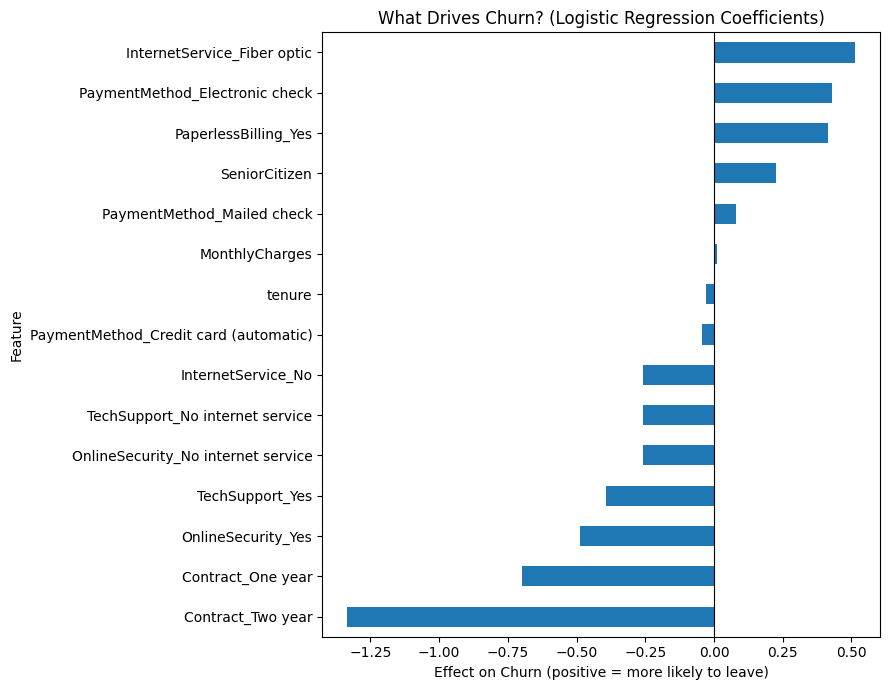

In [16]:
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values()
print(coefs.round(2))

coefs.plot(kind='barh', figsize=(9, 7), title='What Drives Churn? (Logistic Regression Coefficients)')
plt.xlabel('Effect on Churn (positive = more likely to leave)')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

> **So what:** The model correctly predicts **79.6%** of customers it has never seen (AUC **0.837**), beating the **73.5%** baseline of simply guessing that no one leaves. Of the **374** test customers who actually left, it caught **197 (53%)** in advance, and when it flagged a customer as likely to leave, it was right **64%** of the time (197 of 307). The strongest factors **reducing** churn are **two-year contracts (−1.33)** and **one-year contracts (−0.70)**, followed by online security and tech support. The strongest factors **increasing** churn are **fiber optic internet (+0.51)**, **electronic check payments (+0.43)** and **paperless billing (+0.41)**.

**Caveat:** The model shows which factors are linked to churn, not what causes them, and it still misses 177 of 374 customers who left (47%). The coefficient sizes can't be compared directly, because tenure and monthly charges are measured in different units from the yes/no features.

## Revenue at Risk
We use the model to score every **current** customer (those who haven't left) and calculate how much yearly revenue is at risk.

In [17]:
# Churn probability for every customer
df['Churn_Prob'] = model.predict_proba(X)[:, 1]

# Current customers only
active = df[df['Churn'] == 'No'].copy()
high_risk = active[active['Churn_Prob'] >= 0.5]

print('Active customers:', len(active))
print('High-risk active customers (50%+ chance of leaving):', len(high_risk))

revenue_at_risk = (high_risk['MonthlyCharges'] * 12).sum()
expected_loss = (active['Churn_Prob'] * active['MonthlyCharges'] * 12).sum()
lost_revenue = (df[df['Churn'] == 'Yes']['MonthlyCharges'] * 12).sum()

print('\nAnnual revenue from high-risk customers: $', round(revenue_at_risk))
print('Expected annual revenue loss (probability-weighted): $', round(expected_loss))
print('Annual revenue already lost from churned customers: $', round(lost_revenue))

Active customers: 5174
High-risk active customers (50%+ chance of leaving): 533

Annual revenue from high-risk customers: $ 525267
Expected annual revenue loss (probability-weighted): $ 827438
Annual revenue already lost from churned customers: $ 1669570


Contract
Month-to-month    523054.0
One year            2213.0
Name: MonthlyCharges, dtype: float64


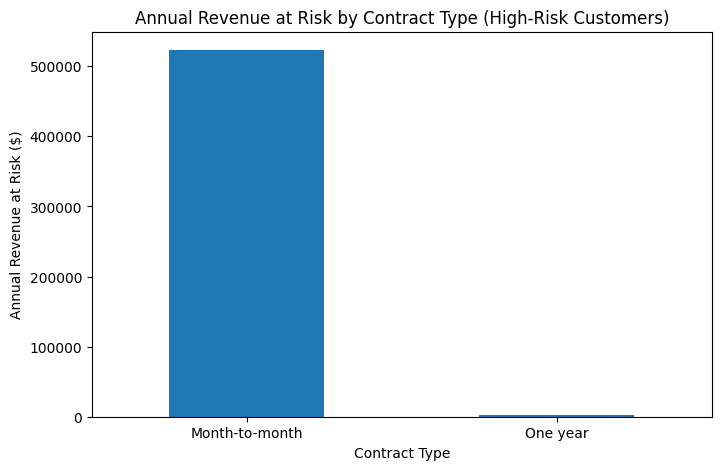

In [18]:
risk_by_contract = (high_risk['MonthlyCharges'] * 12).groupby(high_risk['Contract']).sum()
print(risk_by_contract.round())

risk_by_contract.plot(kind='bar', figsize=(8, 5), title='Annual Revenue at Risk by Contract Type (High-Risk Customers)')
plt.xlabel('Contract Type')
plt.ylabel('Annual Revenue at Risk ($)')
plt.xticks(rotation=0)
plt.show()

> **So what:** Of the **5,174** current customers, **533 (10.3%)** have a 50% or higher chance of leaving. Together they bring in **\$525,267** in annual revenue that is at risk. Weighting every current customer by their churn probability, the company should expect to lose about **\$827,438 per year**. Almost all of the high-risk revenue (**\$523,054, or 99.6%**) comes from **month-to-month** customers, and no two-year customers are high-risk. Retention efforts should therefore focus on month-to-month customers. For context, customers who already left represented **\$1,669,570** in annual revenue.

**Caveat:** These are estimates. They assume monthly charges stay the same for 12 months and that the model's probabilities are accurate. Most customers scored here were also used to train the model, so the probabilities may be slightly optimistic. The 50% cutoff for "high-risk" is also a choice; a lower cutoff would flag more customers and more revenue.

## Recommendations
### Scenario: Move high-risk month-to-month customers to one-year contracts
If a discount or offer convinces **20%** of high-risk month-to-month customers to switch to a one-year contract, their churn rate should drop to the one-year level. *(The 20% conversion rate is an assumption.)*

In [19]:
m2m_rate = churn_by_contract['Month-to-month'] / 100
one_year_rate = churn_by_contract['One year'] / 100

target = high_risk[high_risk['Contract'] == 'Month-to-month']
conversion_rate = 0.20                      # assumption
converted = len(target) * conversion_rate
avg_annual_revenue = target['MonthlyCharges'].mean() * 12

revenue_saved = converted * avg_annual_revenue * (m2m_rate - one_year_rate)

print('High-risk month-to-month customers:', len(target))
print('Customers converted (20%):', round(converted))
print('Estimated annual revenue saved: $', round(revenue_saved))

High-risk month-to-month customers: 531
Customers converted (20%): 106
Estimated annual revenue saved: $ 32890


## Recommendations

1. **Offer annual contracts to month-to-month customers.** They churn at 42.7% (vs. 2.8% for two-year) and hold 99.6% of revenue at risk. Converting 20% could save ~\$32,890/year. *(Impact: High / Feasibility: High)*
2. **Contact high-risk customers monthly.** Use the model to target the 533 customers worth \$525K/year. *(Impact: High / Feasibility: High)*
3. **Push autopay and tech support.** Electronic check (45.3%) and no tech support (41.6%) customers churn the most. *(Impact: Medium / Feasibility: High)*

**Risks:** The 20% conversion rate is an assumption, and discount costs aren't included.

**Next step:** Test the contract offer on a small group first.